In [3]:

import os
import re
import time
import random
import argparse
from collections import Counter
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [4]:
SEED = 42
DATA_DIR = "."  # де лежать Fake.csv і True.csv
FAKE_CSV = os.path.join(DATA_DIR, "Fake.csv")
TRUE_CSV = os.path.join(DATA_DIR, "True.csv")

MAX_VOCAB = 30000
MAX_LEN = 300           # макс довжина послідовності (усікаємо/паддимо)
EMB_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 1
BIDIRECTIONAL = False
DROPOUT = 0.2
BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 6         # для швидкого тесту — збільшуй для кращих результатів
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRINT_EVERY = 1

In [5]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [6]:
def load_and_label(fake_path: str, true_path: str, use_title: bool = True) -> pd.DataFrame:
    # Each CSV expected to have columns: title/text/subject/date (case-insensitive)
    df_fake = pd.read_csv(fake_path)
    df_true = pd.read_csv(true_path)
    df_fake['label'] = 1
    df_true['label'] = 0
    df = pd.concat([df_fake, df_true], ignore_index=True)
    # pick text: Title + Text if available
    text_cols = [c for c in df.columns if c.lower().strip() in ('title', 'text')]
    if use_title and 'title' in [c.lower() for c in text_cols]:
        # attempt to use Title + Text
        def row_text(r):
            t = ""
            if 'title' in map(str.lower, df.columns):
                # access by original case
                title_col = [c for c in df.columns if c.lower() == 'title'][0]
                t += str(r.get(title_col, "")) + " "
            if 'text' in map(str.lower, df.columns):
                text_col = [c for c in df.columns if c.lower() == 'text'][0]
                t += str(r.get(text_col, ""))
            return t
        df['full_text'] = df.apply(row_text, axis=1)
    else:
        # fallback: try 'text' column
        if 'text' in map(str.lower, df.columns):
            text_col = [c for c in df.columns if c.lower() == 'text'][0]
            df['full_text'] = df[text_col].astype(str)
        else:
            raise ValueError("No usable text columns found in CSVs.")
    # drop NA
    df = df[['full_text', 'label']].dropna().reset_index(drop=True)
    return df

In [7]:
TOKEN_RE = re.compile(r"[A-Za-zА-Яа-я0-9]+(?:'[A-Za-z0-9]+)?")

def simple_tokenize(text: str) -> List[str]:
    # lowercase, keep alnum tokens and simple contractions
    text = text.lower()
    tokens = TOKEN_RE.findall(text)
    return tokens


In [8]:
def build_vocab(texts: List[str], max_vocab: int = 30000, min_freq: int = 2) -> Tuple[Dict[str,int], Dict[int,str]]:
    counter = Counter()
    for t in texts:
        tokens = simple_tokenize(t)
        counter.update(tokens)
    # reserve indices: 0 -> PAD, 1 -> UNK
    most_common = [w for w,c in counter.most_common(max_vocab) if c >= min_freq]
    stoi = {"<pad>": 0, "<unk>": 1}
    for i, w in enumerate(most_common, start=2):
        stoi[w] = i
    itos = {i:w for w,i in stoi.items()}
    return stoi, itos

In [9]:
def texts_to_sequences(texts: List[str], stoi: Dict[str,int], max_len: int) -> np.ndarray:
    seqs = []
    unk = stoi.get("<unk>", 1)
    pad = stoi.get("<pad>", 0)
    for t in texts:
        tokens = simple_tokenize(t)
        idxs = [stoi.get(tok, unk) for tok in tokens][:max_len]
        if len(idxs) < max_len:
            idxs = idxs + [pad]*(max_len - len(idxs))
        seqs.append(idxs)
    return np.array(seqs, dtype=np.int64)


In [10]:
class NewsDataset(Dataset):
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        # sequences: (N, L), labels: (N,)
        self.X = torch.from_numpy(sequences).long()
        self.y = torch.from_numpy(labels).float()
    def __len__(self):
        return self.X.size(0)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [11]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(input_size=emb_dim,
                          hidden_size=hidden_dim,
                          num_layers=num_layers,
                          batch_first=True,
                          nonlinearity='tanh',
                          dropout=(dropout if num_layers > 1 else 0.0))
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        emb = self.embedding(x)              # (B, L, emb_dim)
        out, h_n = self.rnn(emb)             # h_n: (num_layers, B, H)
        last = h_n[-1]                       # (B, H)
        logits = self.fc(last).squeeze(1)    # (B,)
        return torch.sigmoid(logits), logits

In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(input_size=emb_dim,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=bidirectional,
                            dropout=(dropout if num_layers > 1 else 0.0))
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, 1)
    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        if self.lstm.bidirectional:
            # concatenate last forward and backward hidden states
            last = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            last = h_n[-1]
        logits = self.fc(last).squeeze(1)
        return torch.sigmoid(logits), logits

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []
    all_preds = []
    all_labels = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        prob, logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item())
        preds = (prob.detach().cpu().numpy() >= 0.5).astype(int)
        all_preds.append(preds)
        all_labels.append(yb.detach().cpu().numpy().astype(int))
    avg_loss = float(np.mean(losses))
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


In [14]:


# -------------------------
# Training / Evaluation
# -------------------------

def evaluate(model, loader, criterion, device, return_probs=True):
    model.eval()
    losses = []
    probs_list = []
    preds_list = []
    labels_list = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            prob, logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs = prob.detach().cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            probs_list.append(probs)
            preds_list.append(preds)
            labels_list.append(yb.detach().cpu().numpy().astype(int))
    avg_loss = float(np.mean(losses)) if losses else 0.0
    probs = np.concatenate(probs_list) if probs_list else np.array([])
    preds = np.concatenate(preds_list) if preds_list else np.array([])
    labels = np.concatenate(labels_list) if labels_list else np.array([])
    acc = accuracy_score(labels, preds) if len(labels)>0 else 0.0
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    roc_auc = roc_auc_score(labels, probs) if (len(np.unique(labels))>1 and len(probs)>0) else 0.0
    return {
        "loss": avg_loss, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "roc_auc": roc_auc,
        "probs": probs, "preds": preds, "labels": labels
    }


In [15]:

# -------------------------
# Plotting helpers
# -------------------------
def plot_train_hist(history: dict, model_name: str):
    epochs = len(history['train_loss'])
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), history['train_loss'], label='train_loss')
    plt.plot(range(1, epochs+1), history['val_loss'], label='val_loss')
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(range(1, epochs+1), history['train_f1'], label='train_f1')
    plt.plot(range(1, epochs+1), history['val_f1'], label='val_f1')
    plt.title(f"{model_name} F1")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()







In [16]:
def plot_confusion_matrix(cm, classes, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes, title=title, ylabel='True label', xlabel='Predicted label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show()

In [17]:
def plot_roc(labels, probs, title="ROC"):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(title); plt.legend()
    plt.show()


In [18]:
# -------------------------
# Full training routine for a single model config
# -------------------------
def run_experiment(config: dict, return_model=False):
    """
    config: dict with keys: model_type: 'rnn'|'lstm', emb_dim, hidden_dim, num_layers, bidirectional, dropout, lr, batch_size, epochs
    """
    print("Experiment config:", config)
    # Load data
    df = load_and_label(FAKE_CSV, TRUE_CSV, use_title=True)
    texts = df['full_text'].tolist()
    labels = df['label'].values.astype(int)

    # train/val/test split
    X_temp, X_test, y_temp, y_test = train_test_split(texts, labels, test_size=0.10, random_state=SEED, stratify=labels)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=SEED, stratify=y_temp)
    # -> approx 80/10/10

    stoi, itos = build_vocab(X_train, max_vocab=MAX_VOCAB, min_freq=2)
    vocab_size = len(stoi)
    print("Vocab size:", vocab_size)

    seq_train = texts_to_sequences(X_train, stoi, MAX_LEN)
    seq_val = texts_to_sequences(X_val, stoi, MAX_LEN)
    seq_test = texts_to_sequences(X_test, stoi, MAX_LEN)

    train_ds = NewsDataset(seq_train, y_train)
    val_ds = NewsDataset(seq_val, y_val)
    test_ds = NewsDataset(seq_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=config['batch_size'], shuffle=False)

    # Init model
    if config['model_type'] == 'rnn':
        model = SimpleRNNClassifier(vocab_size=vocab_size, emb_dim=config['emb_dim'], hidden_dim=config['hidden_dim'],
                                    num_layers=config['num_layers'], dropout=config['dropout'])
    else:
        model = LSTMClassifier(vocab_size=vocab_size, emb_dim=config['emb_dim'], hidden_dim=config['hidden_dim'],
                               num_layers=config['num_layers'], bidirectional=config['bidirectional'], dropout=config['dropout'])
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'train_acc': [], 'val_acc': []}
    best_val_f1 = 0.0
    best_model_state = None

    for epoch in range(1, config['epochs'] + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_res = evaluate(model, val_loader, criterion, DEVICE)
        train_res = evaluate(model, train_loader, criterion, DEVICE)
        history['train_loss'].append(train_res['loss'])
        history['val_loss'].append(val_res['loss'])
        history['train_f1'].append(train_res['f1'])
        history['val_f1'].append(val_res['f1'])
        history['train_acc'].append(train_res['acc'])
        history['val_acc'].append(val_res['acc'])

        if val_res['f1'] > best_val_f1:
            best_val_f1 = val_res['f1']
            best_model_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}

        t1 = time.time()
        if epoch % PRINT_EVERY == 0:
            print(f"Epoch {epoch}/{config['epochs']}  train_loss={train_loss:.4f}  val_loss={val_res['loss']:.4f}  val_f1={val_res['f1']:.4f}  time={t1-t0:.1f}s")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Evaluate on test
    test_res = evaluate(model, test_loader, criterion, DEVICE)
    print("Test results:", test_res)

    # Plots
    plot_train_hist(history, config['model_type'].upper())
    cm = confusion_matrix(test_res['labels'], test_res['preds'])
    plot_confusion_matrix(cm, classes=["real(0)", "fake(1)"], title=f"Confusion - {config['model_type']}")
    if len(test_res['labels'])>0:
        plot_roc(test_res['labels'], test_res['probs'], title=f"ROC - {config['model_type']} (AUC={test_res['roc_auc']:.3f})")

    if return_model:
        return model, history, test_res, stoi
    return history, test_res



In [19]:
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model', choices=['rnn','lstm'], default='lstm')
    parser.add_argument('--epochs', type=int, default=NUM_EPOCHS)
    parser.add_argument('--batch_size', type=int, default=BATCH_SIZE)
    parser.add_argument('--emb_dim', type=int, default=EMB_DIM)
    parser.add_argument('--hidden_dim', type=int, default=HIDDEN_DIM)
    parser.add_argument('--bidirectional', action='store_true')

    import sys
    # Якщо код запускається в Jupyter/Colab — прибираємо сторонні аргументи
    if "ipykernel" in sys.modules:
        args = parser.parse_args(args=[])
    else:
        args = parser.parse_args()

    cfg = {
        'model_type': args.model,
        'emb_dim': args.emb_dim,
        'hidden_dim': args.hidden_dim,
        'num_layers': NUM_LAYERS,
        'bidirectional': args.bidirectional,
        'dropout': DROPOUT,
        'lr': LR,
        'batch_size': args.batch_size,
        'epochs': args.epochs
    }

    run_experiment(cfg, return_model=False)


Experiment config: {'model_type': 'lstm', 'emb_dim': 100, 'hidden_dim': 128, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64, 'epochs': 6}
Vocab size: 30002
Epoch 1/6  train_loss=0.5884  val_loss=0.5592  val_f1=0.7717  time=406.2s
Epoch 2/6  train_loss=0.4683  val_loss=0.3017  val_f1=0.8936  time=270.4s
Epoch 3/6  train_loss=0.2286  val_loss=0.1692  val_f1=0.9533  time=192.6s
Epoch 4/6  train_loss=0.1258  val_loss=0.1138  val_f1=0.9705  time=193.1s
Epoch 5/6  train_loss=0.0523  val_loss=0.0264  val_f1=0.9938  time=196.1s
Epoch 6/6  train_loss=0.0174  val_loss=0.0204  val_f1=0.9957  time=191.8s
Test results: {'loss': 0.020949371103328507, 'acc': 0.9955456570155902, 'prec': 0.9970111016225448, 'rec': 0.9944633730834753, 'f1': 0.9957356076759062, 'roc_auc': 0.9993257666496468, 'probs': array([1.2452482e-03, 9.9962389e-01, 3.2155334e-03, ..., 9.9895239e-01,
       8.8146585e-04, 1.3015752e-03], shape=(4490,), dtype=float32), 'preds': array([0, 1, 0, .

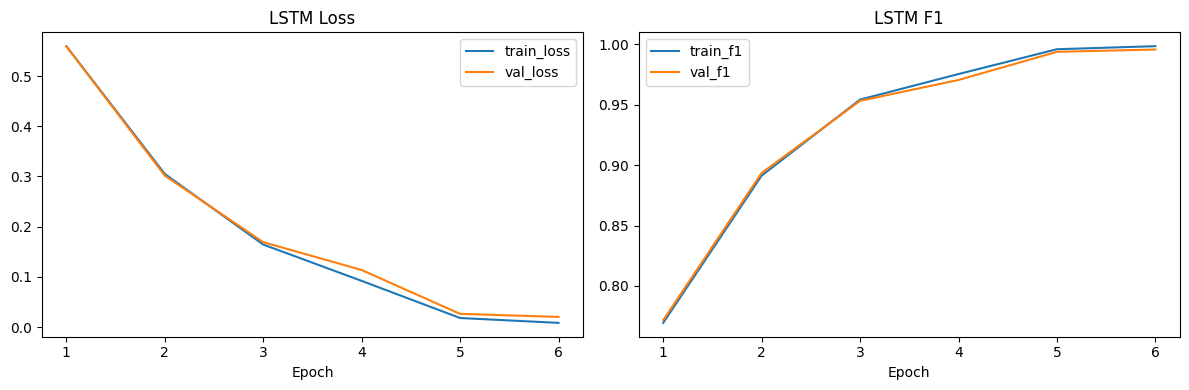

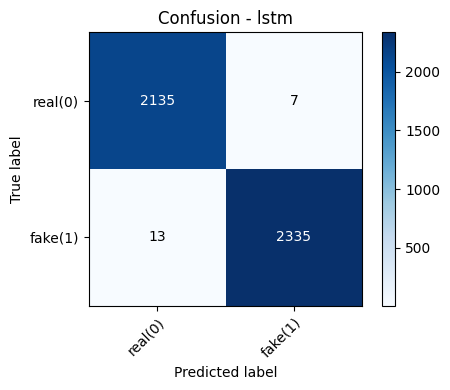

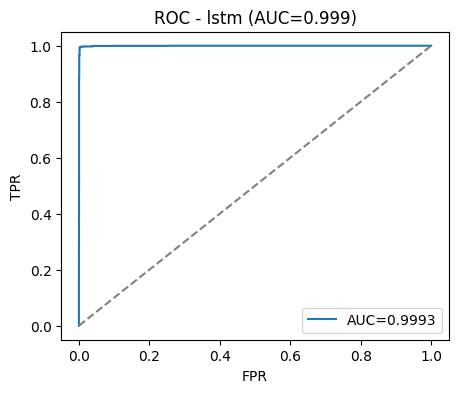

In [20]:
main()